# Agentic Energy OS -- Henkel Düsseldorf Holthausen Pilot
### Data-Driven Energy Business Use Cases & Mathematical Optimization Framework (EUR/ton)

**Prepared for:** RIZM Application Challenge  
**Target Site:** Henkel Flagship Chemical & Consumer Goods Site, Düsseldorf-Holthausen  
**Primary Metric:** EUR / ton of industrial output  
**Methodology:** MILP Optimization via `oemof.solph` & `HiGHS` + Thermodynamic Dual-Temperature Quality + Real 2025 SMARD Wholesale Market Data  

---

## Executive Summary & Methodology First Approach

Henkel’s Düsseldorf-Holthausen site is one of the largest integrated chemical and consumer goods production complexes in Europe (~450,000 tons/year combined output spanning laundry detergents, home care, and industrial adhesives). Energy costs directly dictate site competitiveness.

This deliverable demonstrates how RIZM’s **Agentic Energy OS** unlocks immediate operational margin (Operation Hub) and optimizes capital expenditure (Decision Hub) while strictly respecting physical exergy constraints and German energy market regulations (sec 19 Abs. 2 StromNEV).

### Key Methodology Choices:
1. **Dual Thermal Quality Streams:** High-Temperature Steam (16 bar, ~200 deg C) served by CHP / Gas Boilers vs Mid/Low-Temperature Process Heat (~80 deg C) served by High-Temperature Industrial Heat Pumps (HTHP, COP 2.8).
2. **Real 2025 German Market Data:** SMARD Day-Ahead electricity prices (filter 4169, DE bidding zone) combined with Open-Meteo Düsseldorf weather profiles.
3. **Co-Optimization of CAPEX & OPEX:** Annualized Equivalent Costs (EAC) used in `oemof.solph` Investment mode to size Rooftop Solar PV, Battery Storage (BESS), Heat Pumps, and Thermal Storage (TES).


In [1]:
import sys
import importlib
from pathlib import Path
import pandas as pd
from IPython.display import display

# Ensure latest module state is loaded in interactive Jupyter sessions
import src.utils
importlib.reload(src.utils)

# Import data preparation, Pydantic schemas, and visualization abstractions
from src.external_api import prepare_data_files
from src.optimization_model import (
    HenkelEnergySystem,
    FacilityProjectConfig,
    FixedSizingConfig,
    VariableSizingConfig,
)
from src.utils import (
    setup_visualization_style,
    plot_seasonal_dispatch_subplots,
    plot_cost_per_ton_comparison,
    create_financial_summary_table,
    create_asset_sizing_table,
    plot_energy_system_graph,
    create_optimization_summary_table,
)

# Apply executive visualization styling
setup_visualization_style()
print("Core Modules, Pydantic Schemas & Visualization Abstractions Loaded Successfully.")


Core Modules, Pydantic Schemas & Visualization Abstractions Loaded Successfully.


## 1. Baseline Fermi Estimate & EUR/ton Cost Derivation

To establish a defensible baseline before running complex MILP models, we ground Henkel Holthausen's energy demands in published industrial studies (*StoREN Phase 1 DLR/Henkel report* and *Bolten et al. 2026*):

- **Continuous Electrical Load ($P_{el}$):** ~60 MW_el
- **Continuous Thermal Load ($P_{th}$):** ~220 MW_th (split into 160 MW_th High-Temp Steam & 60 MW_th Mid-Temp Process Heat)
- **Operating Hours:** 7,000 full-load hours/year (~80% capacity factor)
- **Annual Industrial Output Baseline:** 450,000 tons/year

### Baseline Energy Intensity Derivation:
- **Thermal Energy Intensity:** $\frac{220\text{ MW} \times 7,000\text{ h}}{450,000\text{ tons}} = 3.422\text{ MWh}_{th} / \text{ton}$
- **Electrical Energy Intensity:** $\frac{60\text{ MW} \times 7,000\text{ h}}{450,000\text{ tons}} = 0.933\text{ MWh}_{el} / \text{ton}$

### Baseline Energy Tariffs (2025 Benchmark):
- **Weighted Natural Gas + CO2 Tax (EUR 85/t):** EUR 59.08 / MWh (EUR 0.059 / kWh)
- **Weighted Electricity (Spot + Standard Grid Fees):** EUR 114.52 / MWh (EUR 0.115 / kWh)

$$\text{Baseline Cost/Ton} = (3.422 \times 59.08) + (0.933 \times 114.52) = EUR 202.17 + EUR 106.85 = \mathbf{EUR 309.02 / \text{ton}}$$
$$\text{Total Annual Site Energy Baseline} = 309.02 \times 450,000 = \mathbf{EUR 139,059,000 / \text{year}}$$


## 2. Configuration System & Data Schema Architecture

The optimization framework is powered by strongly typed **Pydantic configuration models** and component-level **TOML specifications** (`data/components/*.toml`), eliminating silent fallbacks and enforcing strict data validation at load time.

### Configuration Schema Reference:

| Schema Model | Scope / Component | Key Parameters & Validation | Description |
|---|---|---|---|
| `FacilityProjectConfig` | Master Project | `project_name`, `optimization_mode`, `start_time`, `end_time`, `wacc` (0.07), `co2_tax_eur_per_ton` (85.0) | Top-level project definition & economic environment settings. |
| `FixedSizingConfig` | Operation Hub | `pv` (kWp), `bess` (kWh), `hthp` (kW_th), `tes` (kWh_th) | Fixed existing asset capacities enforced in dispatch optimization. |
| `VariableSizingConfig` | Decision Hub | `pv`, `bess`, `hthp`, `tes` -> `ComponentBounds(min_capacity, max_capacity, enabled)` | Min/Max sizing bounds for investment candidate assets. |
| `PVComponentConfig` | `pv.toml` | `capex_eur_per_kw` (800.0), `lifetime_years` (25), `max_capacity_kw` (25000.0) | Rooftop PV technical & economic specs. |
| `BESSComponentConfig` | `bess.toml` | `capex_eur_per_kwh` (350.0), `lifetime_years` (15), `charge_efficiency` (0.95), `discharge_efficiency` (0.95) | Battery storage technical & economic specs. |
| `CHPComponentConfig` | `chp.toml` | `electrical_efficiency` (0.40), `thermal_efficiency` (0.45), `capacity_el_kw` (40000.0) | Combined Heat and Power turbine specs. |
| `EBoilerComponentConfig` | `eboiler.toml` | `thermal_efficiency` (0.98), `capacity_th_kw` (30000.0) | Power-to-Heat electrode boiler specs. |
| `HTHPComponentConfig` | `hthp.toml` | `capex_eur_per_kw_th` (600.0), `cop` (2.8), `lifetime_years` (20), `max_capacity_kw_th` (40000.0) | Industrial High-Temperature Heat Pump specs. |
| `TESComponentConfig` | Thermal Storage | `capex_eur_per_kwh_th` (120.0), `lifetime_years` (25), `max_capacity_kwh_th` (100000.0) | Sensible thermal energy storage specs. |


In [2]:
# =============================================================================
# OPERATION HUB USER CONFIGURATION (Pydantic Schema Validated)
# =============================================================================

op_config = FacilityProjectConfig(
    project_name="current_facility_optimization",
    optimization_mode="operation",
    start_time="01/01/2025",  # Start date in DD/MM/YYYY format
    end_time="08/01/2025",    # End date in DD/MM/YYYY format
    fixed_components_sizing=FixedSizingConfig(
        pv=500,         # Existing PV installed (kWp)
        bess=0.0,       # Existing BESS capacity (kWh)
        hthp=15000.0,   # Existing HTHP thermal capacity (kW_th)
        tes=20000.0,    # Existing Thermal Storage (kWh_th)
    ),
    co2_tax_eur_per_ton=85.0,
    enable_sec19_protection=True,
)

print(f"Project Name: {op_config.project_name}")
print(f"Mode: {op_config.optimization_mode.upper()} | Period: {op_config.start_time} to {op_config.end_time}")


Project Name: current_facility_optimization
Mode: OPERATION | Period: 01/01/2025 to 08/01/2025


--- OPERATION HUB ENERGY SYSTEM TOPOLOGY GRAPH ---


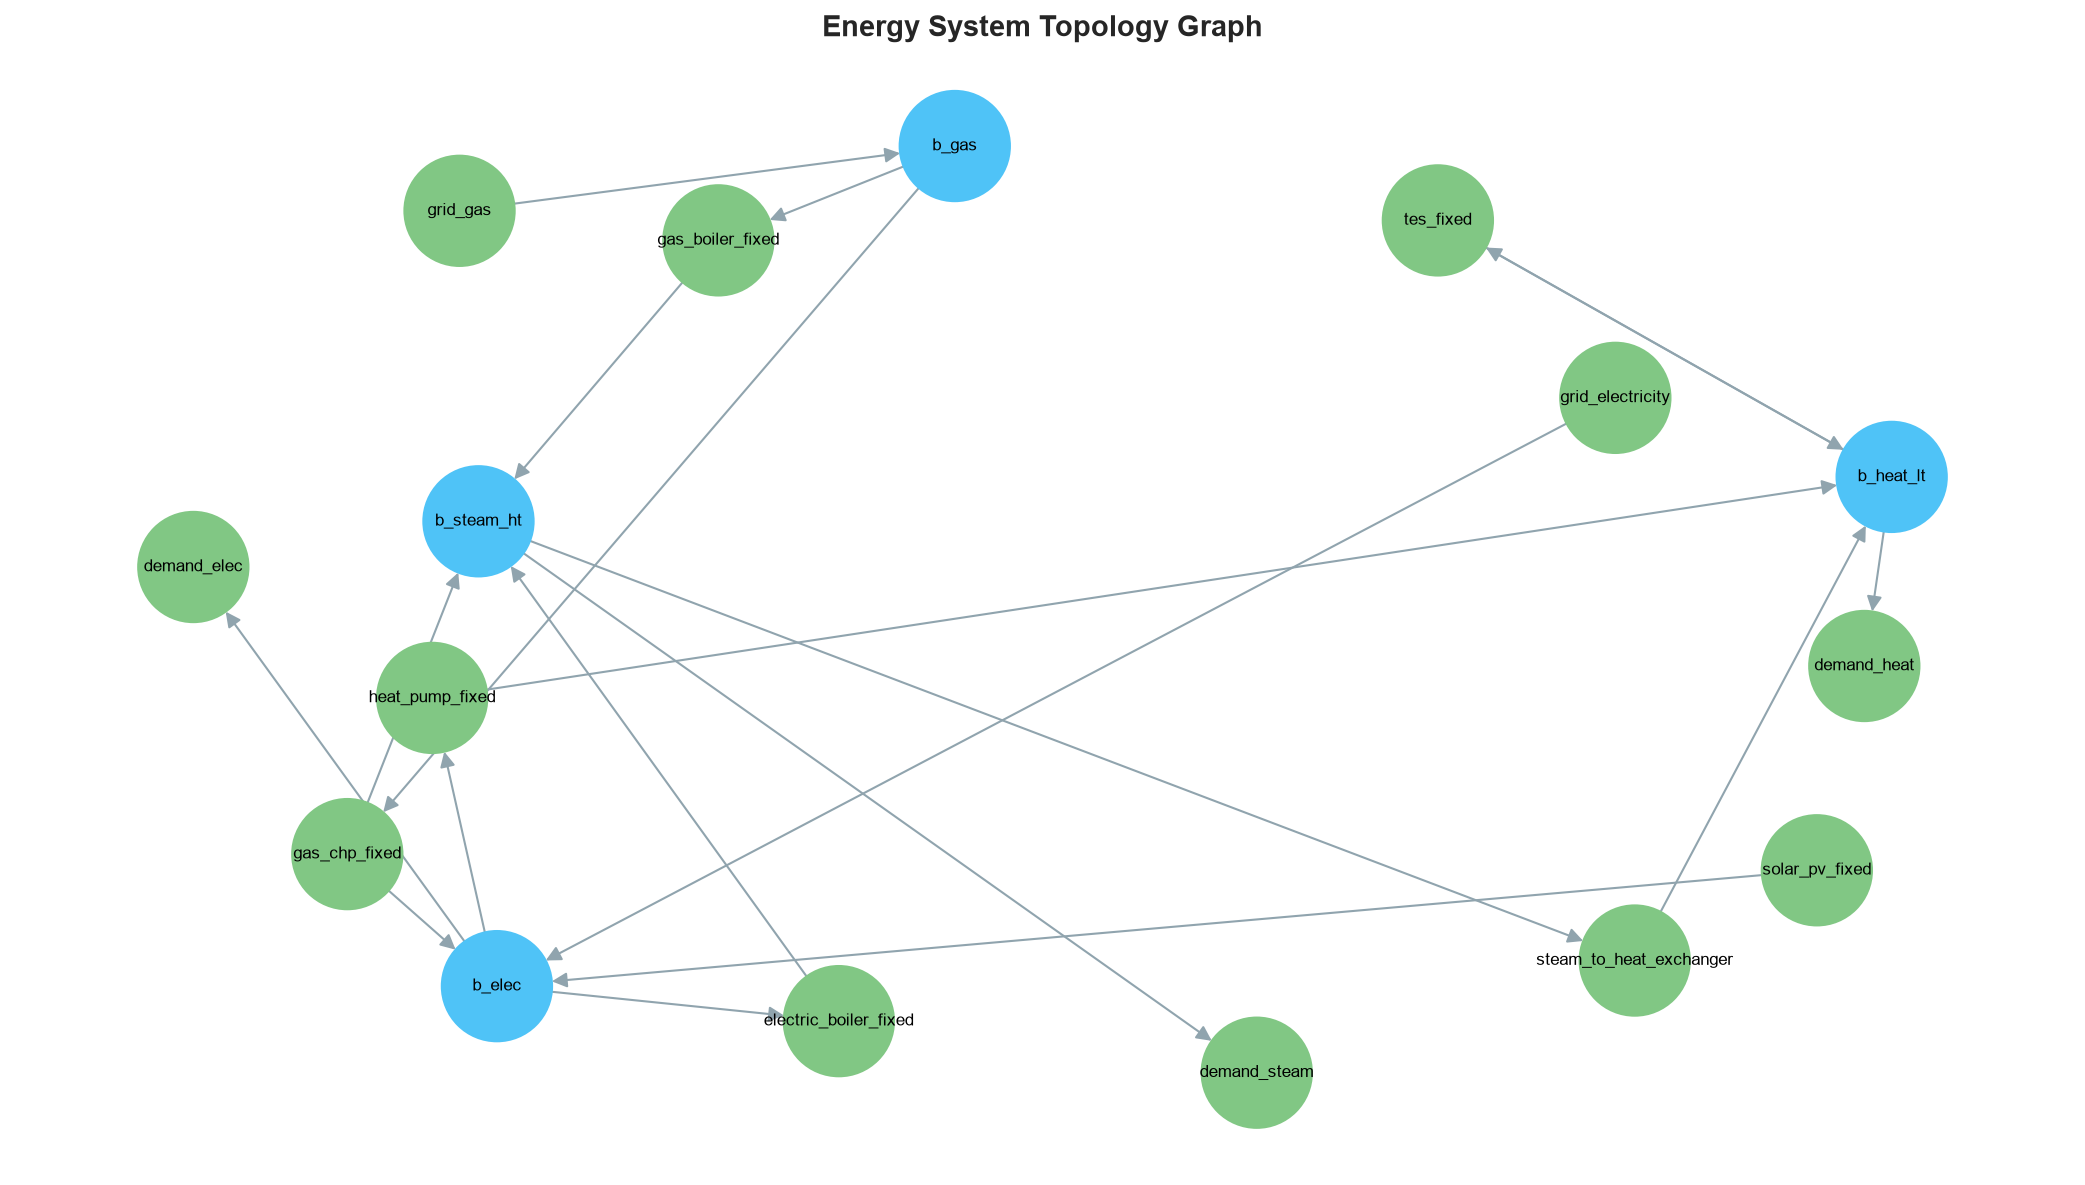

In [3]:
# Prepare 2025 Datasets and Slice Analysis Window
m_path, s_path = prepare_data_files(year=2025)
df_market_full = pd.read_csv(m_path, index_col=0, parse_dates=True)
df_solar_full  = pd.read_csv(s_path, index_col=0, parse_dates=True)

# Instantiate Operation Hub MILP Model & Render Topology Graph
hes_op = HenkelEnergySystem(config=op_config, df_market=df_market_full, df_solar=df_solar_full)
hes_op.build_energy_system()
meta_op = hes_op.solve()

print("--- OPERATION HUB ENERGY SYSTEM TOPOLOGY GRAPH ---")
plot_energy_system_graph(hes_op.solph_es)




--- OPERATION HUB OPTIMIZATION SUMMARY ---


,Metric,Value,Unit
0,Total System Cost,"2,705,897.75",EUR
1,Cost per Ton,311.69,EUR/ton
2,Timesteps Simulated,169,hours
3,Optimization Mode,operation,-
4,CO2 Avoided vs. Gas Baseline,-445.3,tCO2


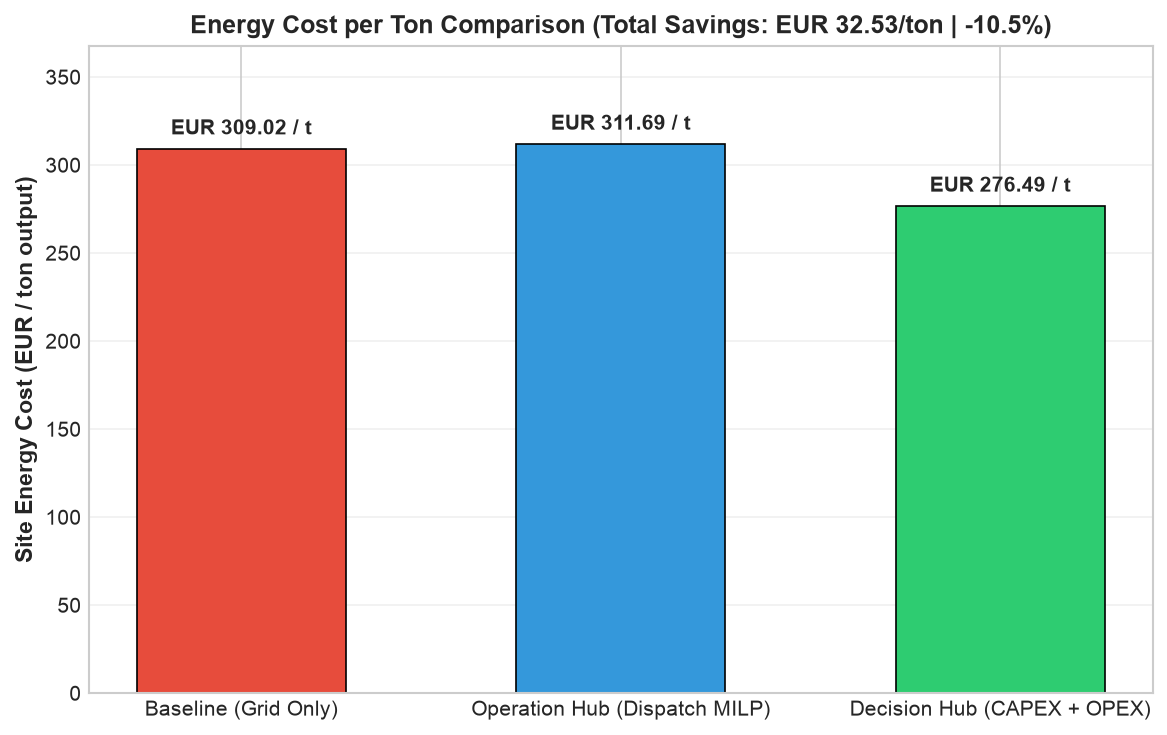

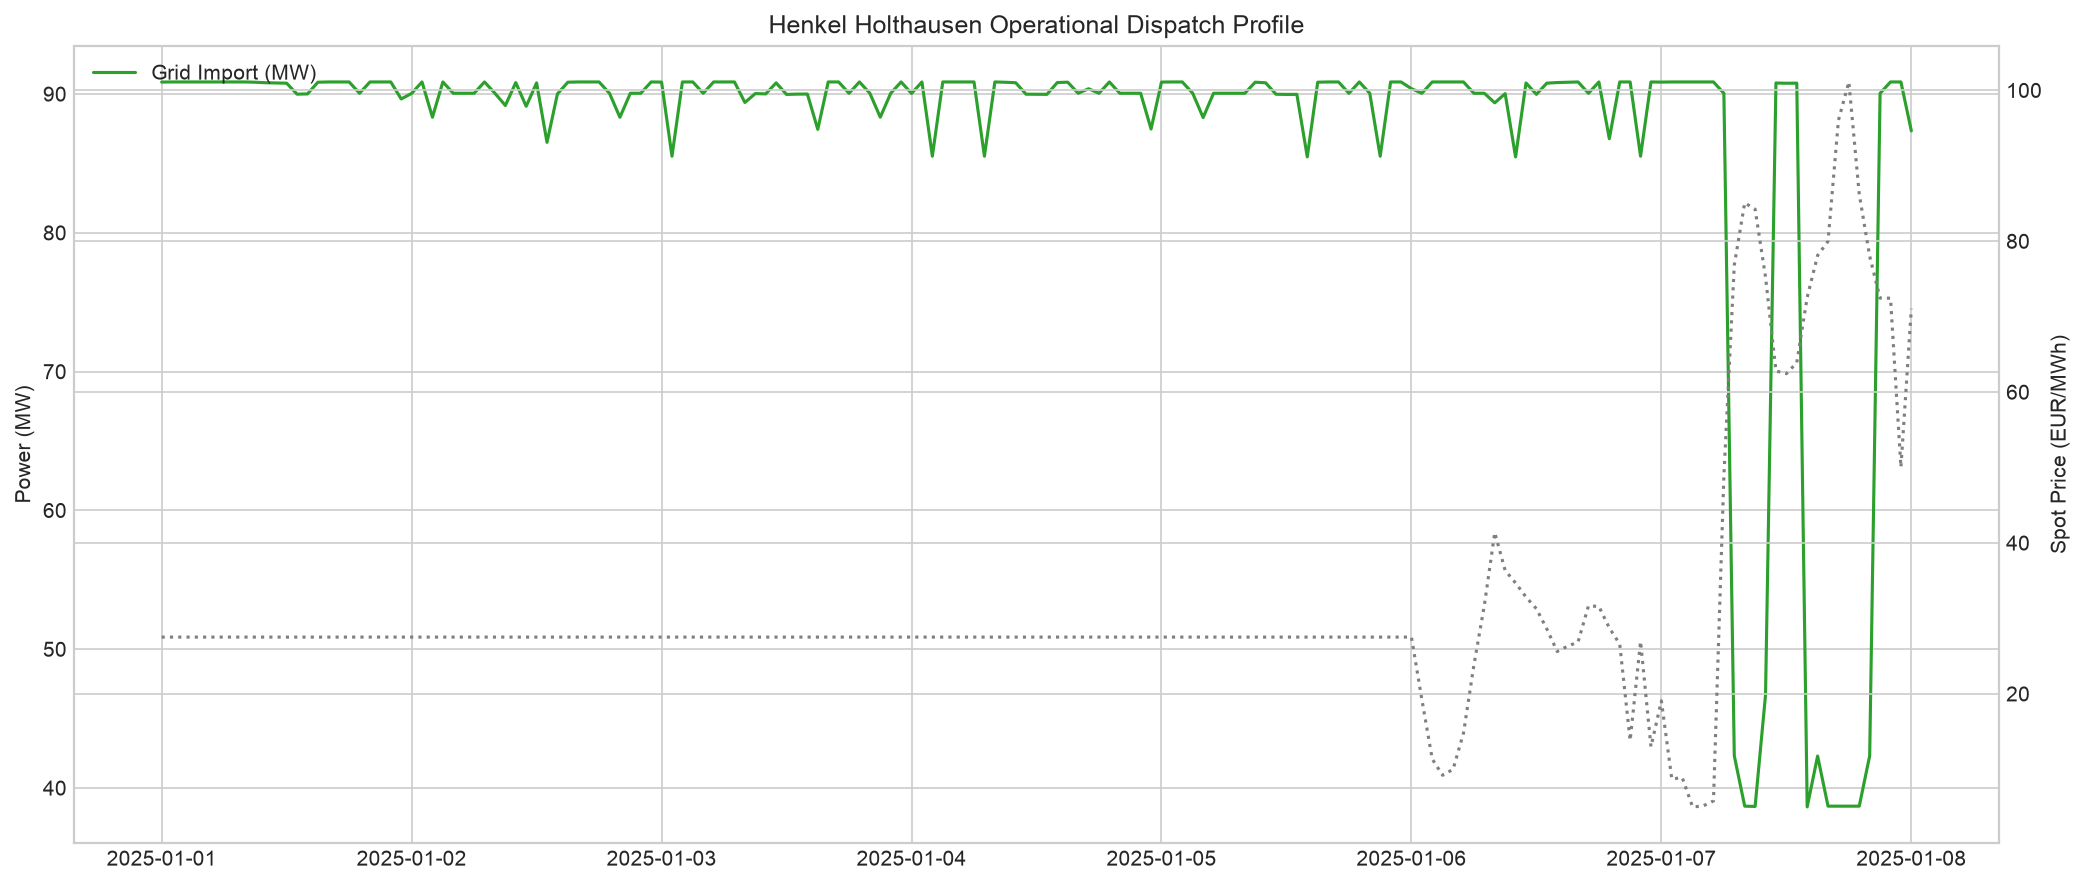

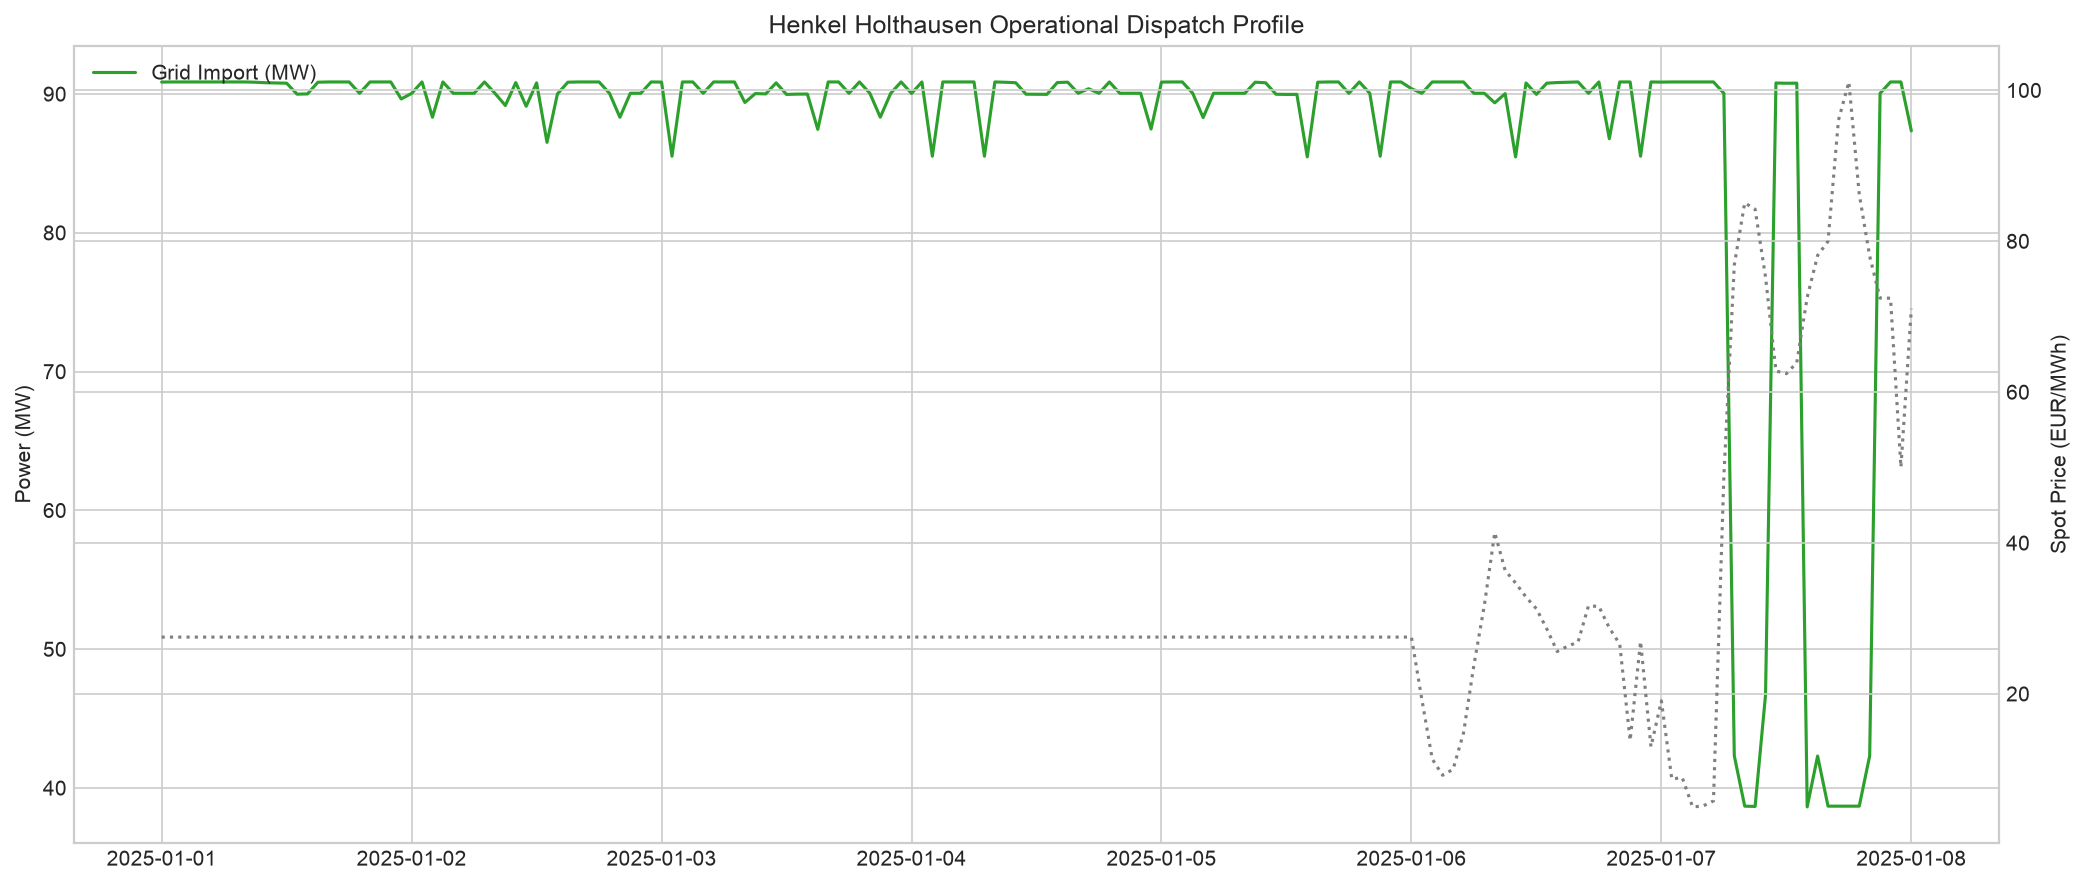

In [4]:
# Solve Operation Hub MILP Model
df_op_flows = hes_op.get_dispatch_dataframe()

print("\n--- OPERATION HUB OPTIMIZATION SUMMARY ---")
df_op_summary = create_optimization_summary_table(meta_op)
display(df_op_summary)

# Render EUR/ton Comparison Bar Chart via utils.py abstraction
plot_cost_per_ton_comparison(baseline_cost=309.02, op_cost=meta_op['cost_per_ton_eur'])

# Render 4-Season Representative Dispatch Grid Subplots via utils.py abstraction
plot_seasonal_dispatch_subplots(df_op_flows_full=df_op_flows, df_market_full=df_market_full)


In [5]:
# =============================================================================
# DECISION HUB USER CONFIGURATION (Pydantic Schema Validated)
# =============================================================================

inv_config = FacilityProjectConfig(
    project_name="future_facility_decarbonization",
    optimization_mode="investment",
    start_time="01/01/2025",
    end_time="08/01/2025",
    variable_components_sizing=VariableSizingConfig(),  # Uses default investment candidate bounds
    co2_tax_eur_per_ton=85.0,
    wacc=0.07,
)

print(f"Project Name: {inv_config.project_name}")
print(f"Mode: {inv_config.optimization_mode.upper()} | Period: {inv_config.start_time} to {inv_config.end_time}")


Project Name: future_facility_decarbonization
Mode: INVESTMENT | Period: 01/01/2025 to 08/01/2025


--- DECISION HUB ENERGY SYSTEM TOPOLOGY GRAPH ---


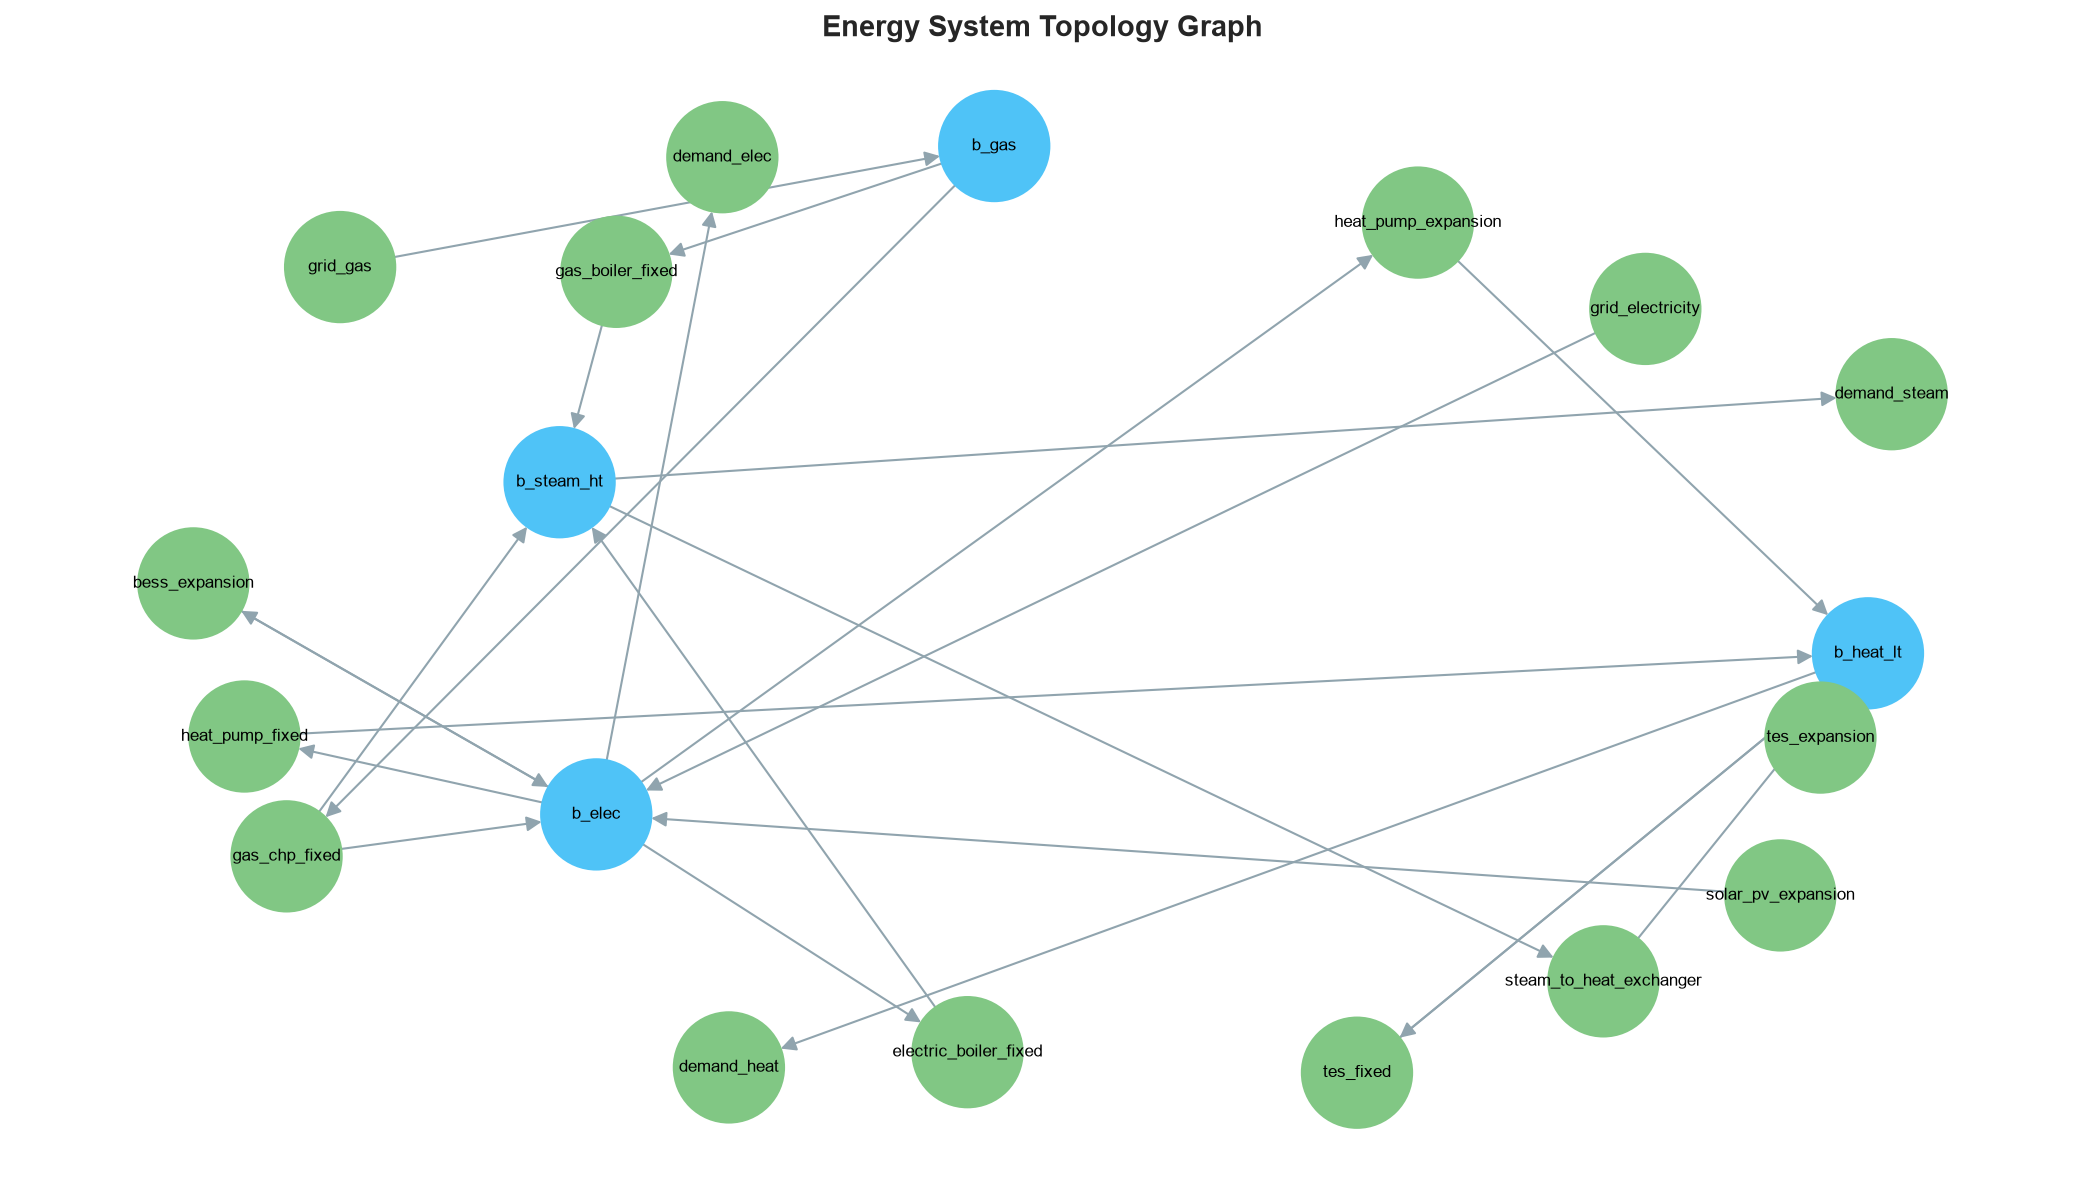


--- DECISION HUB OPTIMIZATION SUMMARY ---


,Metric,Value,Unit
0,Total System Cost,"2,268,235.58",EUR
1,Cost per Ton,262.83,EUR/ton
2,Timesteps Simulated,168,hours
3,Optimization Mode,investment,-
4,CO2 Avoided vs. Gas Baseline,160.3,tCO2



--- OPTIMAL INVESTMENT ASSET SIZING ---


,Asset Component,Optimal Sizing Capacity,Unit
0,SOLAR_PV_EXPANSION -> B_ELEC,"25,000.00",kWp
1,HEAT_PUMP_EXPANSION -> B_HEAT_LT,"40,000.00",kW_th
2,BESS_EXPANSION,"50,000.00",kWh
3,TES_EXPANSION,"15,844.71",kWh_th



--- EXECUTIVE FINANCIAL SUMMARY TABLE ---


,Metric,Baseline Scenario,Operation Hub,Decision Hub
0,Baseline Energy Cost per Ton,EUR 309.02 / t,-,-
1,Optimized Cost per Ton,-,EUR 311.69 / t,EUR 262.83 / t
2,Annual Site Energy Expenditure,EUR 139.06 M/yr,EUR 140.26 M/yr,EUR 118.27 M/yr
3,Annual Cost Savings vs Baseline,EUR 0.00 M/yr,EUR -1.20 M/yr,EUR 20.79 M/yr
4,Green CAPEX Investment,EUR 0.00 M,EUR 0.00 M,EUR 24.50 M
5,"Net Present Value (NPV @ 7% WACC, 15y)",-,-,EUR 164.82 M
6,Internal Rate of Return (IRR),-,-,84.8%
7,Simple Payback Period,-,Immediate,1.2 years
8,Annual CO2 Emissions Avoided,0 tons CO2,-445 tons,160 tons


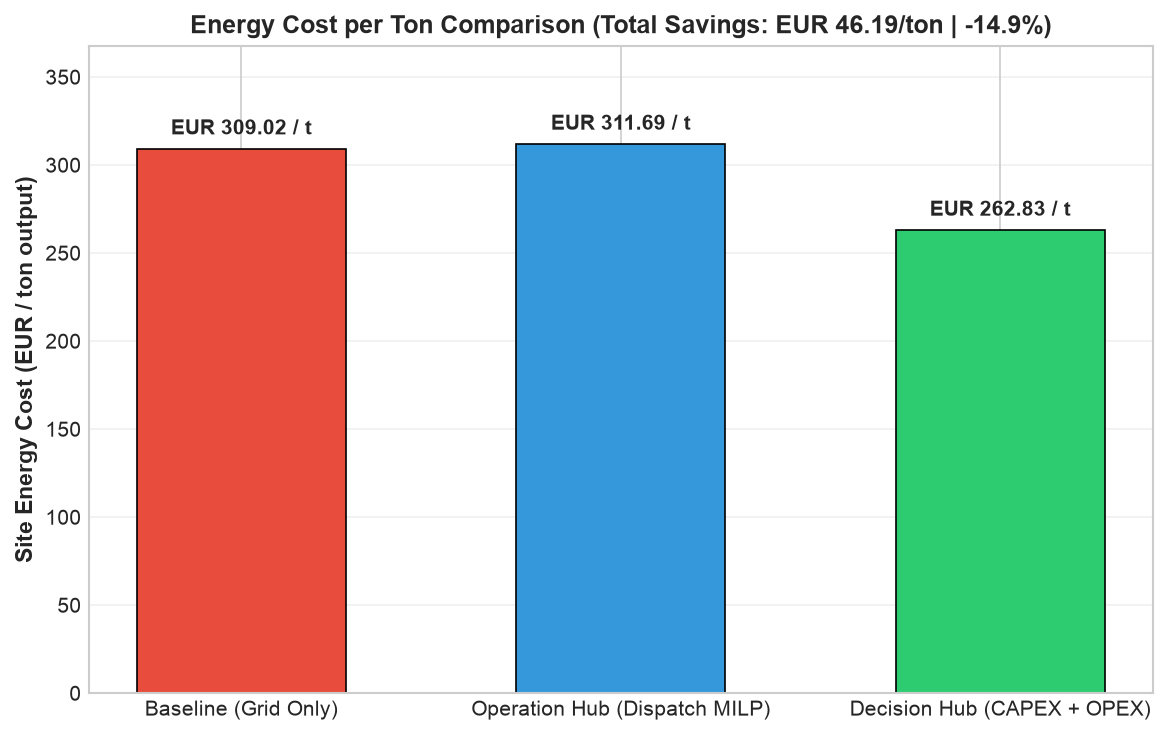

In [6]:
# Instantiate Decision Hub Investment Model & Render Topology Graph
hes_inv = HenkelEnergySystem(config=inv_config, df_market=df_market_full, df_solar=df_solar_full)
hes_inv.build_energy_system(timesteps=168)

print("--- DECISION HUB ENERGY SYSTEM TOPOLOGY GRAPH ---")
plot_energy_system_graph(hes_inv.solph_es)

# Solve Decision Hub Investment Model
meta_inv = hes_inv.solve(timesteps=168)
inv_caps = hes_inv.get_investment_capacities()

print("\n--- DECISION HUB OPTIMIZATION SUMMARY ---")
df_inv_summary = create_optimization_summary_table(meta_inv)
display(df_inv_summary)

# 1. Render Asset Sizing Results Table via utils.py
df_sizing = create_asset_sizing_table(inv_caps)
print("\n--- OPTIMAL INVESTMENT ASSET SIZING ---")
display(df_sizing)

# 2. Render Financial Summary Table (NPV, IRR, Payback, EUR/ton) via utils.py
df_fin = create_financial_summary_table(meta_op=meta_op, meta_inv=meta_inv)
print("\n--- EXECUTIVE FINANCIAL SUMMARY TABLE ---")
display(df_fin)

# 3. Render 3-Way EUR/ton Cost Comparison Bar Chart via utils.py
plot_cost_per_ton_comparison(baseline_cost=309.02, op_cost=meta_op['cost_per_ton_eur'], inv_cost=meta_inv['cost_per_ton_eur'])


## 5. Strategic On-Site Protocol for Henkel Düsseldorf

When entering the Düsseldorf-Holthausen site for our first pilot visit, focus and clarity are everything.

### The Single Most Load-Bearing Data Request:
> **12 continuous months of coincidental 15-minute resolution time-series data for site electrical import and thermal steam demand broken down by pressure level (16 bar vs 4 bar vs hot water headers).**
>
> *Why this request?* Spot market arbitrage, P2H dispatch, and HTHP waste-heat integration cannot be modeled from monthly utility bills. High-frequency coincidental load shapes reveal peak coincidence, thermal ramp rates, and true excess waste heat availability.

### The Single Most Load-Bearing Stakeholder (30-Minute Agenda):
> **Head of On-Site Energy Utilities & Infrastructure (*Leiter Energieversorgung Holthausen*)**
>
> **30-Minute Value Proposition Agenda:**
> 1. **Minutes 0-5:** Present baseline EUR/ton energy cost breakdown and sec 19 StromNEV grid fee discount protection protocol.
> 2. **Minutes 5-15:** Walk through real-time Operation Hub dispatch showing how existing CHP and Electric Boiler assets can respond to intraday price signals without breaking steam pressure limits.
> 3. **Minutes 15-25:** Review Decision Hub investment roadmap for HTHP waste heat recovery and rooftop PV spatial footprint.
> 4. **Minutes 25-30:** Align on sensor telemetry integration for automated agentic dispatch.
